<a href="https://colab.research.google.com/github/Tuleen-Alshehri/final-project/blob/main/02_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Phase-2**

**First step**
downloaded the libraries I needed.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# step-1
from google.colab import files
uploaded = files.upload()

print(uploaded)


Saving 01_cleaning.ipynb to 01_cleaning (5).ipynb
{'01_cleaning (5).ipynb': b'{\n  "nbformat": 4,\n  "nbformat_minor": 0,\n  "metadata": {\n    "colab": {\n      "provenance": []\n    },\n    "kernelspec": {\n      "name": "python3",\n      "display_name": "Python 3"\n    },\n    "language_info": {\n      "name": "python"\n    }\n  },\n  "cells": [\n    {\n      "cell_type": "markdown",\n      "source": [\n        "# **First step**"\n      ],\n      "metadata": {\n        "id": "NYsWC2j6ux2K"\n      }\n    },\n    {\n      "cell_type": "markdown",\n      "source": [\n        "**In the first step, I downloaded the libraries I needed.**"\n      ],\n      "metadata": {\n        "id": "0YzkTYC-vCZE"\n      }\n    },\n    {\n      "cell_type": "code",\n      "execution_count": 105,\n      "metadata": {\n        "id": "10ot1nX0riZm"\n      },\n      "outputs": [],\n      "source": [\n        "import pandas as pd\\n",\n        "import numpy as np\\n",\n        "import matplotlib.pyplot as plt

In [ ]:
#step-2
#explore the data
df = pd.read_csv("cleaned_titanic.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.describe)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  
0      0         A/5 21171   7.2500        S  
1      0          PC 17599  65.6344        C  
2      0  STON/O2. 3101282   7.9250        S  
3      0            113803  53.1000        S  
4      0            373450   8.0500        S  
(891, 11)
<class 'pandas.core.frame.Da

step-2

In [ ]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'],drop_first=True)
#I use drop_first To reduce the number of columns
print(df.head)

<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name   Age  SibSp  Parch  \
0                              Braund, Mr. Owen Harris  22.0      1      0   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                               Heikkinen, Miss. Laina  26.0      0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                             Allen, Mr. William Henry  35.0      0      0   
..                                           

step-3

In [ ]:
pclass_map = {1: 3, 2: 2, 3: 1} #
df['Pclass_ordinal'] = df['Pclass'].map(pclass_map)

print(df[['Pclass', 'Pclass_ordinal']].head())
print(df[['Pclass', 'Pclass_ordinal']].tail())

   Pclass  Pclass_ordinal
0       3               1
1       1               3
2       3               1
3       1               3
4       3               1
     Pclass  Pclass_ordinal
886       2               2
887       1               3
888       3               1
889       1               3
890       3               1


step-4 Domain Feature-1

In [ ]:
df['family_size'] = df['SibSp'] + df['Parch']
print(df[['family_size']].head())
print(df[['family_size']].tail())

   family_size
0            1
1            1
2            0
3            1
4            0
     family_size
886            0
887            0
888            3
889            0
890            0


step-5  Domain Feature-2

In [ ]:
df["fare_per_person"] = df["Fare"] / (df["family_size"])
print(df[['fare_per_person']].head())
print(df[['fare_per_person']].tail())

   fare_per_person
0           7.2500
1          65.6344
2              inf
3          53.1000
4              inf
     fare_per_person
886              inf
887              inf
888         7.816667
889              inf
890              inf


step-6  Interaction Feature

In [ ]:
df["Age_Pclass_interaction"] = df["Age"] * (df["Pclass_ordinal"])
print(df[['Age_Pclass_interaction','Age','Pclass_ordinal']].head())
print(df[['Age_Pclass_interaction','Age','Pclass_ordinal']].tail())


   Age_Pclass_interaction   Age  Pclass_ordinal
0                    22.0  22.0               1
1                   114.0  38.0               3
2                    26.0  26.0               1
3                   105.0  35.0               3
4                    35.0  35.0               1
     Age_Pclass_interaction   Age  Pclass_ordinal
886                    54.0  27.0               2
887                    57.0  19.0               3
888                    28.0  28.0               1
889                    78.0  26.0               3
890                    32.0  32.0               1


step-7  Log Transform

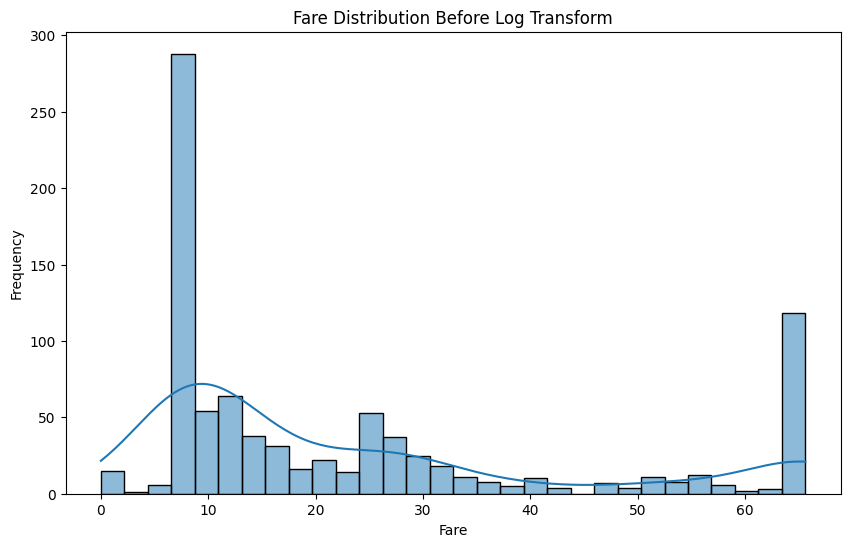

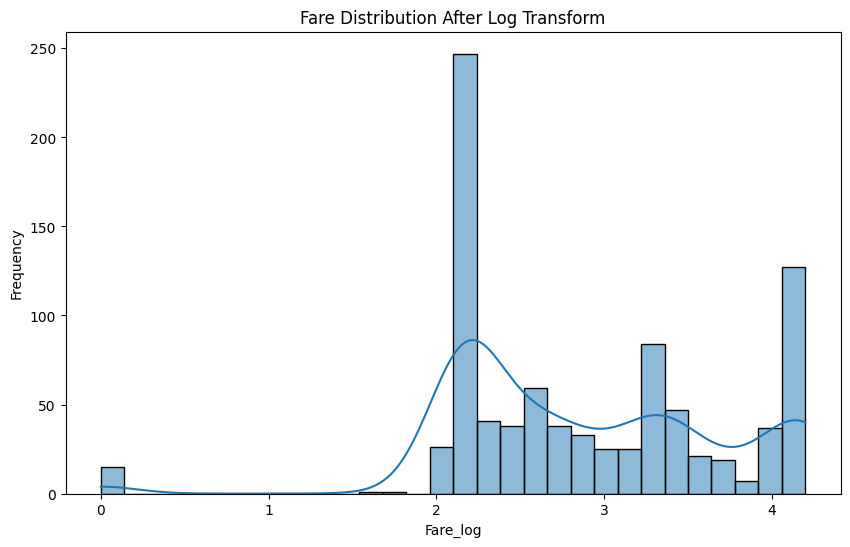

      Fare  Fare_sqrt
0   7.2500   2.692582
1  65.6344   8.101506
2   7.9250   2.815138
3  53.1000   7.286975
4   8.0500   2.837252
      Fare  Fare_sqrt
886  13.00   3.605551
887  30.00   5.477226
888  23.45   4.842520
889  30.00   5.477226
890   7.75   2.783882


<Axes: xlabel='Fare', ylabel='Count'>

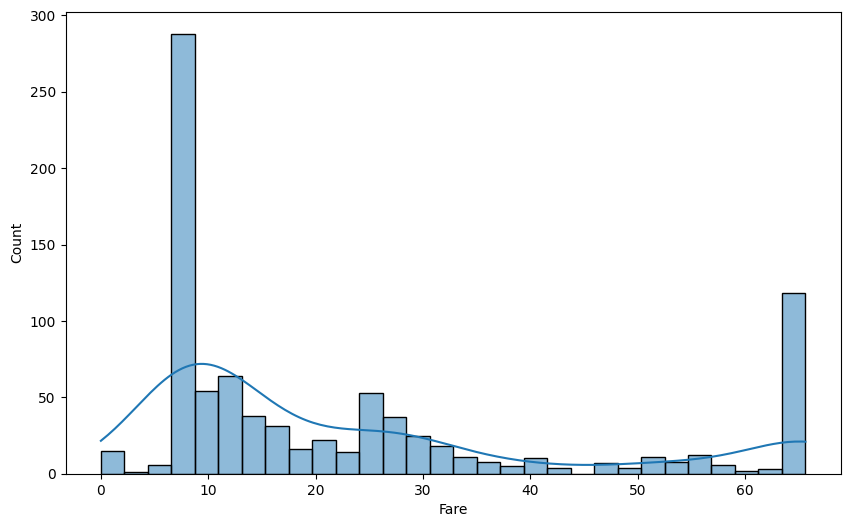

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], kde=True, bins=30)
plt.title('Fare Distribution Before Log Transform')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show

df["Fare_log"] = np.log1p(df["Fare"])

plt.figure(figsize=(10, 6))
sns.histplot(df['Fare_log'], kde=True, bins=30)
plt.title('Fare Distribution After Log Transform')
plt.xlabel('Fare_log')
plt.ylabel('Frequency')
plt.show()

#sqrt

df["Fare_sqrt"] = np.sqrt(df["Fare"])

print(df[["Fare", "Fare_sqrt"]].head())
print(df[["Fare", "Fare_sqrt"]].tail())

plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], kde=True, bins=30)

step-8

In [ ]:
bins = [0,18,50,100]
labels = ['child','adult','old']
df['Age_category'] = pd.cut(df['Age'], bins=bins, labels=labels)
print(df[['Age','Age_category']].head(15))

     Age Age_category
0   22.0        adult
1   38.0        adult
2   26.0        adult
3   35.0        adult
4   35.0        adult
5   28.0        adult
6   54.0          old
7    2.5        child
8   27.0        adult
9   14.0        child
10   4.0        child
11  54.5          old
12  20.0        adult
13  39.0        adult
14  14.0        child


step-9

In [ ]:
scaler = StandardScaler()
df['Fare_scaled'] = scaler.fit_transform(df[['Fare']])
print(df[['Fare','Fare_scaled']].head(15))

       Fare  Fare_scaled
0    7.2500    -0.820552
1   65.6344     2.031623
2    7.9250    -0.787578
3   53.1000     1.419297
4    8.0500    -0.781471
5    8.4583    -0.761525
6   51.8625     1.358843
7   21.0750    -0.145178
8   11.1333    -0.630847
9   30.0708     0.294282
10  16.7000    -0.358904
11  26.5500     0.122285
12   8.0500    -0.781471
13  31.2750     0.353109
14   7.8542    -0.791036


step-10

In [ ]:
corr = df.corr(numeric_only=True)
high_corr = (corr > 0.95)
drop = []

for col in high_corr.columns:
    if high_corr[col].drop(col).any():
        drop.append(col)

df = df.drop(columns=drop)
print(drop)

['Fare', 'Fare_log', 'Fare_sqrt', 'Fare_scaled']


step-11

In [ ]:
print(df.shape)
print(df.isnull().sum())
print(df.head)

step-12

In [ ]:
df.to_csv("features_titanic.csv", index=False)
from google.colab import files
files.download("features_titanic.csv")

In [ ]:
import os
os.listdir()